# Analyse Logs

Downloads a single episode replay by `EPISODE_ID`, saves to `14-analyse_logs/00-raw/`, then extracts the observations for a chosen `PLAYER` index.

The last section lists all episodes for a submission and filters to games where our agent was **player 0**.

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
EPISODE_ID   = 76367802   # episode to download and inspect
PLAYER       = 1          # agent index to extract (0 or 1)
SUBMISSION_ID = None      # set to an int to list episodes; None = fetch latest

In [6]:
import json
import requests
from pathlib import Path

KAGGLE_API_I = "https://www.kaggle.com/api/i"
GET_REPLAY   = f"{KAGGLE_API_I}/competitions.EpisodeService/GetEpisodeReplay"
LIST_EPISODES = f"{KAGGLE_API_I}/competitions.EpisodeService/ListEpisodes"

raw_dir = Path("14-analyse_logs/00-raw")
raw_dir.mkdir(parents=True, exist_ok=True)

out_path = raw_dir / f"episode-{EPISODE_ID}.json"

if out_path.exists():
    print(f"Already cached: {out_path}")
else:
    resp = requests.post(GET_REPLAY, json={"episodeId": EPISODE_ID}, timeout=60)
    resp.raise_for_status()
    out_path.write_text(resp.text, encoding="utf-8")
    print(f"Downloaded: {out_path}  ({out_path.stat().st_size / 1024:.1f} kB)")

with open(out_path) as f:
    raw = json.load(f)

print(f"Players : {raw['info']['TeamNames']}")
print(f"Rewards : {raw['rewards']}")
print(f"Steps   : {len(raw['steps'])}")
print(f"\nPlayer {PLAYER}: {raw['info']['TeamNames'][PLAYER]}")

Already cached: 14-analyse_logs\00-raw\episode-76367802.json
Players : ['This.Mike.Guy', 'Tien-Thinh']
Rewards : [1, -1]
Steps   : 185

Player 1: Tien-Thinh


## Extract player data

Pulls every timestep's observation for `PLAYER` and attaches the action taken at that step.

In [7]:
player_dir = Path(f"14-analyse_logs/01-player{PLAYER}")
player_dir.mkdir(parents=True, exist_ok=True)

steps = []
for step_data in raw["steps"]:
    obs = step_data[PLAYER]["observation"]
    obs["action"] = step_data[PLAYER]["action"]
    steps.append(obs)

out_player = player_dir / f"episode-{EPISODE_ID}.json"
with open(out_player, "w") as f:
    json.dump(steps, f)

print(f"Saved {len(steps)} steps → {out_player}")
steps[0]

Saved 185 steps → 14-analyse_logs\01-player1\episode-76367802.json


{'angular_velocity': 0.039652842961090645,
 'comet_planet_ids': [],
 'comets': [],
 'fleets': [],
 'initial_planets': [[0, -1, 96.81054740406452, 68.42761465914135, 1.0, 14, 1],
  [1, -1, 31.572385340858645, 96.81054740406452, 1.0, 14, 1],
  [2, -1, 68.42761465914135, 3.189452595935478, 1.0, 14, 1],
  [3, -1, 3.189452595935478, 31.572385340858645, 1.0, 14, 1],
  [4, -1, 76.33600595808012, 97.92382056341651, 1.0, 78, 1],
  [5, -1, 2.0761794365834874, 76.33600595808012, 1.0, 78, 1],
  [6, -1, 97.92382056341651, 23.663994041919878, 1.0, 78, 1],
  [7, -1, 23.663994041919878, 2.0761794365834874, 1.0, 78, 1],
  [8, -1, 64.55234700450167, 96.38974268559613, 2.09861228866811, 38, 3],
  [9, -1, 3.610257314403867, 64.55234700450167, 2.09861228866811, 38, 3],
  [10, -1, 96.38974268559613, 35.44765299549833, 2.09861228866811, 38, 3],
  [11, -1, 35.44765299549833, 3.610257314403867, 2.09861228866811, 38, 3],
  [12, -1, 89.46505588394592, 86.87621229390697, 2.09861228866811, 13, 3],
  [13, -1, 13.12

## Non-moving planets

Uses `initial_planets` from step 0 (fixed starting coordinates) and the `is_planet_moving` condition.

In [14]:
from collections import defaultdict

fleets = defaultdict(list)
for step in steps:
    for fleet in step['fleets']:
        fleet_id = fleet[0]
        fleet_player = fleet[1]
        fleet_x = fleet[2]
        fleet_y = fleet[3]
        if fleet_player == PLAYER:
            fleets[fleet_id].append((fleet_x, fleet_y))
fleets

defaultdict(list,
            {1: [(26.060892890350885, 2.388224236355507),
              (27.366996638916948, 2.558261817611624),
              (28.67310038748301, 2.7282993988677413),
              (29.979204136049074, 2.8983369801238585),
              (31.285307884615136, 3.0683745613799758),
              (32.5914116331812, 3.238412142636093)],
             4: [(26.060892890350885, 2.388224236355507),
              (27.366996638916948, 2.558261817611624),
              (28.67310038748301, 2.7282993988677413),
              (29.979204136049074, 2.8983369801238585),
              (31.285307884615136, 3.0683745613799758),
              (32.5914116331812, 3.238412142636093)],
             5: [(26.060892890350885, 2.388224236355507),
              (27.366996638916948, 2.558261817611624),
              (28.67310038748301, 2.7282993988677413),
              (29.979204136049074, 2.8983369801238585),
              (31.285307884615136, 3.0683745613799758),
              (32.5914116331812, 3

In [27]:
import math

CENTER_X, CENTER_Y = 50.0, 50.0
MAX_SPEED = 6.0

def is_planet_moving(planet):
    orbital_radius = math.hypot(planet[2] - CENTER_X, planet[3] - CENTER_Y)
    return orbital_radius + planet[4] < 50

initial_planets = steps[0]["initial_planets"]
non_moving = [p for p in initial_planets if not is_planet_moving(p)]

# Pre-compute speed radius for each non-moving planet
planet_data = [
    {
        "id": p[0], "owner": p[1], "x": p[2], "y": p[3],
        "radius": p[4], "ships": p[5],
    }
    for p in non_moving
]

print(f"Non-moving: {len(non_moving)} / {len(initial_planets)}   Fleets: {len(fleets)}")

Non-moving: 20 / 32   Fleets: 74


In [31]:
import plotly.graph_objects as go

PLAYER_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig = go.Figure()
fig.update_layout(
    width=700, height=700,
    xaxis=dict(range=[0, 100], showgrid=False, zeroline=False),
    yaxis=dict(range=[0, 100], showgrid=False, zeroline=False, scaleanchor="x"),
    # paper_bgcolor="#0a0a1a",
    plot_bgcolor="#0a0a1a",
    title=dict(text=f"Player {PLAYER} — episode {EPISODE_ID}", font_color="white"),
    showlegend=False,
)

shapes = []

# Sun
shapes.append(dict(type="circle", xref="x", yref="y",
                   x0=CENTER_X-10, y0=CENTER_Y-10,
                   x1=CENTER_X+10, y1=CENTER_Y+10,
                   fillcolor="gold", opacity=0.5, line_width=0))

# Non-moving planets
for p in planet_data:
    color = "#555555" if p["owner"] == -1 else PLAYER_COLORS[p["owner"] % len(PLAYER_COLORS)]
    r, x, y = p["radius"], p["x"], p["y"]

    # Planet body
    shapes.append(dict(type="circle", xref="x", yref="y",
                       x0=x-r, y0=y-r, x1=x+r, y1=y+r,
                       fillcolor=color, opacity=0.85, line_width=0))

    # Label
    fig.add_trace(go.Scatter(x=[x], y=[y], mode="text",
                             text=[str(p["id"])],
                             textfont=dict(size=9, color="white")))

fig.update_layout(shapes=shapes)

# Fleet trajectories
palette = go.layout.colorway if hasattr(go.layout, "colorway") else [
    "#636efa","#ef553b","#00cc96","#ab63fa","#ffa15a","#19d3f3","#ff6692","#b6e880",
]
for i, (fleet_id, positions) in enumerate(fleets.items()):
    xs, ys = zip(*positions)
    color = palette[i % len(palette)]
    fig.add_trace(go.Scatter(
        x=xs, y=ys, mode="lines+markers",
        line=dict(color=color, width=1.5),
        marker=dict(size=4, color=color),
        name=f"fleet {fleet_id}",
        hovertemplate=f"fleet {fleet_id}<br>x=%{{x:.1f}}, y=%{{y:.1f}}<extra></extra>",
    ))
    # Spawn marker
    fig.add_trace(go.Scatter(x=[xs[0]], y=[ys[0]], mode="markers+text",
                             marker=dict(symbol="circle", size=8, color=color),
                             text=[str(fleet_id)], textposition="top right",
                             textfont=dict(size=8, color=color)))
    # Last-seen marker
    fig.add_trace(go.Scatter(x=[xs[-1]], y=[ys[-1]], mode="markers",
                             marker=dict(symbol="x", size=8, color=color)))

fig.show()

## Build df_fleet / df_planets (from player steps)

Same pipeline as `12-fleet_movement.ipynb`, using `steps` (player `PLAYER`'s observations).

In [45]:
import json
import math
import pandas as pd
import numpy as np

fleet_rows = []
planet_rows = []

for step, obs in enumerate(steps):
    step

    for f in obs["fleets"]:
        if f[1] == PLAYER:
            fleet_rows.append({
                "step":           step,
                "id":             f[0],
                "owner":          f[1],
                "x":              f[2],
                "y":              f[3],
                "angle":          f[4],
                "from_planet_id": f[5],
                "ships":          f[6],
            })

    for p in obs["planets"]:
        planet_rows.append({
            "step":       step,
            "id":         p[0],
            "owner":      p[1],
            "x":          p[2],
            "y":          p[3],
            "radius":     p[4],
            "ships":      p[5],
            "production": p[6],
        })

df_fleet   = pd.DataFrame(fleet_rows).drop_duplicates(subset=["step", "id"]).reset_index(drop=True)
df_planets = pd.DataFrame(planet_rows).drop_duplicates(subset=["step", "id"]).reset_index(drop=True)

print(df_fleet.shape, df_planets.shape)
df_fleet.head()

(1978, 8) (6180, 8)


,step,id,owner,x,y,angle,from_planet_id,ships
0,11,1,1,26.060893,2.388224,0.129459,7,3
1,12,1,1,27.366997,2.558262,0.129459,7,3
2,13,1,1,28.673100,2.728299,0.129459,7,3
3,14,1,1,29.979204,2.898337,0.129459,7,3
4,14,4,1,26.060893,2.388224,0.129459,7,3


In [46]:
df = df_fleet.merge(
    df_planets,
    left_on=["step", "from_planet_id"],
    right_on=["step", "id"],
    how="left",
    suffixes=("_fleet", "_planet"),
)

print(df.shape)
df

(1978, 15)


,step,id_fleet,owner_fleet,x_fleet,y_fleet,angle,from_planet_id,ships_fleet,id_planet,owner_planet,x_planet,y_planet,radius,ships_planet,production
0,11,1,1,26.060893,2.388224,0.129459,7,3,7,1,23.663994,2.076179,1.000000,18,1
1,12,1,1,27.366997,2.558262,0.129459,7,3,7,1,23.663994,2.076179,1.000000,19,1
2,13,1,1,28.673100,2.728299,0.129459,7,3,7,1,23.663994,2.076179,1.000000,20,1
3,14,1,1,29.979204,2.898337,0.129459,7,3,7,1,23.663994,2.076179,1.000000,18,1
4,14,4,1,26.060893,2.388224,0.129459,7,3,7,1,23.663994,2.076179,1.000000,18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1973,179,268,1,87.455282,94.749910,1.052247,11,3,11,0,35.447653,3.610257,2.098612,452,3
1974,180,268,1,88.108076,95.893886,1.052247,11,3,11,0,35.447653,3.610257,2.098612,455,3
1975,181,268,1,88.760870,97.037861,1.052247,11,3,11,0,35.447653,3.610257,2.098612,458,3
1976,182,268,1,89.413664,98.181836,1.052247,11,3,11,0,35.447653,3.610257,2.098612,461,3


In [47]:
MAX_SPEED = 6.0

def fleet_speed(nb_ships):
    if nb_ships <= 1:
        return 1.0
    ratio = math.log(nb_ships) / math.log(1000.0)
    return 1.0 + (MAX_SPEED - 1.0) * max(0.0, min(1.0, ratio)) ** 1.5

df["speed"] = df["ships_fleet"].apply(fleet_speed)

df["dist_from_origin"] = np.sqrt(
    (df["x_planet"] - df["x_fleet"]) ** 2 +
    (df["y_planet"] - df["y_fleet"]) ** 2
)

df = df.sort_values(["id_fleet", "step"]).reset_index(drop=True)
df["x_prev"] = df.groupby("id_fleet")["x_fleet"].shift(1)
df["y_prev"] = df.groupby("id_fleet")["y_fleet"].shift(1)
df["dist_from_prev"] = np.sqrt(
    (df["x_prev"] - df["x_fleet"]) ** 2 +
    (df["y_prev"] - df["y_fleet"]) ** 2
)
df = df.drop(columns=["x_prev", "y_prev"])

df[["step", "id_fleet", "ships_fleet", "speed", "dist_from_origin", "dist_from_prev"]].head(20)

,step,id_fleet,ships_fleet,speed,dist_from_origin,dist_from_prev
0,11,1,3,1.317126,2.417126,NaN
1,12,1,3,1.317126,3.734251,1.317126
2,13,1,3,1.317126,5.051377,1.317126
3,14,1,3,1.317126,6.368502,1.317126
4,15,1,3,1.317126,7.685628,1.317126
5,16,1,3,1.317126,9.002753,1.317126
6,14,4,3,1.317126,2.417126,NaN
7,15,4,3,1.317126,3.734251,1.317126
8,16,4,3,1.317126,5.051377,1.317126
9,17,4,3,1.317126,6.368502,1.317126


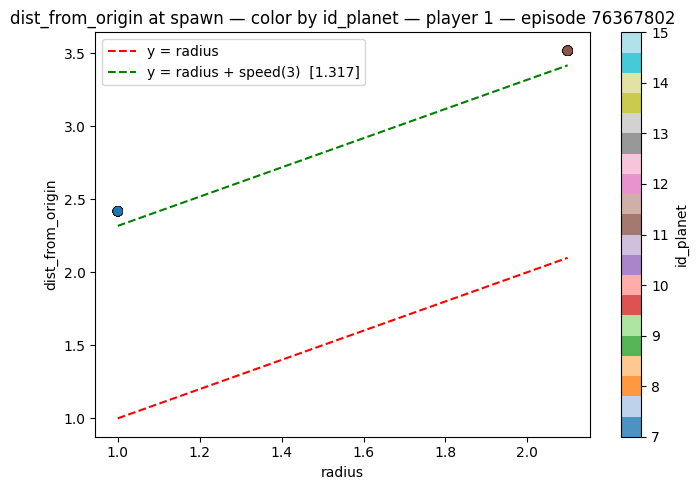

In [48]:
import matplotlib.pyplot as plt

df_spawn = df.query("dist_from_prev.isna()").copy()

speed_3 = fleet_speed(3)
r_min, r_max = df_spawn["radius"].min(), df_spawn["radius"].max()
ref_r = [r_min, r_max]

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df_spawn["radius"],
    df_spawn["dist_from_origin"],
    c=df_spawn["id_planet"],
    cmap="tab20",
    alpha=0.8,
    s=50,
    edgecolors="k",
    linewidths=0.3,
)

ax.plot(ref_r, ref_r, "r--", lw=1.5, label="y = radius")
ax.plot(ref_r, [r + speed_3 for r in ref_r], "g--", lw=1.5, label=f"y = radius + speed(3)  [{speed_3:.3f}]")

ax.set_xlabel("radius")
ax.set_ylabel("dist_from_origin")
ax.set_title(f"dist_from_origin at spawn — color by id_planet — player {PLAYER} — episode {EPISODE_ID}")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("id_planet")

ax.legend()
plt.tight_layout()
plt.show()

In [50]:
df_spawn = df.query("dist_from_prev.isna()").copy()
df_spawn["id_planet"] = df_spawn["id_planet"].astype("category")

speed_3 = fleet_speed(3)
ref_r = [df_spawn["radius"].min(), df_spawn["radius"].max()]

palette = [
    "#636efa", "#ef553b", "#00cc96", "#ab63fa", "#ffa15a", "#19d3f3",
    "#ff6692", "#b6e880", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf",
]
id_colors = {
    pid: palette[i % len(palette)]
    for i, pid in enumerate(df_spawn["id_planet"].cat.categories)
}
colors = df_spawn["id_planet"].map(id_colors)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_spawn["radius"],
    y=df_spawn["dist_from_origin"],
    mode="markers",
    marker=dict(
        size=8,
        color=colors,
        opacity=0.8,
        line=dict(width=0.5, color="black"),
    ),
    customdata=df_spawn[["id_planet"]],
    hovertemplate="radius=%{x:.3f}<br>dist_from_origin=%{y:.3f}<br>id_planet=%{customdata[0]}<extra></extra>",
    name="spawn points",
))

fig.add_trace(go.Scatter(
    x=ref_r,
    y=ref_r,
    mode="lines",
    line=dict(color="red", dash="dash", width=2),
    name="y = radius",
))

fig.add_trace(go.Scatter(
    x=ref_r,
    y=[r + speed_3 for r in ref_r],
    mode="lines",
    line=dict(color="green", dash="dash", width=2),
    name=f"y = radius + speed(3)  [{speed_3:.3f}]",
))

fig.update_layout(
    width=700,
    height=500,
    xaxis_title="radius",
    yaxis_title="dist_from_origin",
    title=f"dist_from_origin at spawn — color by id_planet — player {PLAYER} — episode {EPISODE_ID}",
    template="plotly_dark",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)

fig.show()